# WDI Panel-Aligned Time-Aware Modeling

This notebook evaluates whether a longer historical WDI dataset with fewer features can compete with the shorter merged WHO/World Bank analytical panel.

Main idea:

- WDI has many more years.
- The merged panel has richer features but fewer years.
- We attach panel metadata (`region`, `income_group`, `status`) to WDI country-years.
- For years before the panel starts, we use the earliest available panel metadata for each country.
- For years after the panel ends, we use the latest available panel metadata for each country.
- We train WDI-specific models and evaluate on years that overlap with the panel test period.

### Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from life_expectancy.analysis.diagnostics import (
    group_error_table,
    plot_predicted_vs_actual,
    plot_residual_hist,
    plot_residuals_vs_predicted,
    worst_errors_table,
)
from life_expectancy.data.loading import load_source
from life_expectancy.data.utils import resolve_project_path
from life_expectancy.data.preprocessing import build_processed_dataset
from life_expectancy.data.standardization import standardize
from life_expectancy.data.wdi import pivot_wdi, attach_panel_metadata_to_wdi
from life_expectancy.modeling.experiments.wdi import fit_evaluate_wdi_model, make_panel_overlap_split
from life_expectancy.features.temporal import make_country_lag_features
from life_expectancy.modeling.models.baselines import ridge_cv
from life_expectancy.modeling.train_eval import regression_metrics

### Config and Output Folders

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

YEAR_COL = config["features"].get("year_col", "year")
PANEL_TARGET = config["features"].get("target_col", "life_expectancy")
RANDOM_STATE = config.get("random_seed", 42)

WDI_TARGET_CODE = "SP.DYN.LE00.IN"
WDI_TARGET = "life_expectancy"

LAGS = (1, 2, 3)
VAL_YEARS = 1
TEST_YEARS = config.get("modeling", {}).get("split", {}).get("test_years", 3)

RESTRICT_TO_PANEL_COUNTRIES = True

TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Project root:", PROJECT_ROOT)
print("Panel target:", PANEL_TARGET)
print("WDI target:", WDI_TARGET)

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Panel target: life_expectancy
WDI target: life_expectancy


## 1. Build the processed panel

In [3]:
panel, _ = build_processed_dataset(config)

wdi_raw = load_source(config, "wdi")
wdi_config = config["data"]["raw_sources"]["wdi"]
wdi_standardized = standardize(wdi_raw, wdi_config)
wdi_panel, wdi_summary = pivot_wdi(wdi_standardized, config)

wdi_panel.head(), wdi_summary

(       country  year  SP.DYN.LE00.IN
 0  Afghanistan  1960          32.799
 1  Afghanistan  1961          33.291
 2  Afghanistan  1962          33.757
 3  Afghanistan  1963          34.201
 4  Afghanistan  1964          34.673,
 {'input_rows': 266,
  'rows_after_indicator_filter': 266,
  'n_year_columns': 65,
  'indicator_codes': ['SP.DYN.LE00.IN'],
  'rows_dropped_all_nan': 0,
  'output_rows': 16926,
  'output_cols': 3})

## 2. Attach panel metadata to WDI

For each country-year:

- If the year exists in the processed panel, use that year's `region`, `income_group`, and `status`.
- If the WDI year is before the panel starts, use the earliest available panel metadata for that country.
- If the WDI year is after the panel ends, use the latest available panel metadata for that country.

This lets WDI use the same country metadata schema as the panel models.

In [4]:
metadata_cols = [
    col for col in ["region", "income_group", "status"] if col in panel.columns
]

if not metadata_cols:
    raise KeyError("No metadata columns found in panel.")

join_key = "country_code"

if join_key not in panel.columns or join_key not in wdi_panel.columns:
    join_key = "country"

panel_meta = panel[
    [join_key, YEAR_COL, *metadata_cols]
].dropna(subset=[join_key, YEAR_COL]).copy()

panel_meta = panel_meta.sort_values([join_key, YEAR_COL])
panel_meta = panel_meta.drop_duplicates([join_key, YEAR_COL], keep="last")

if RESTRICT_TO_PANEL_COUNTRIES:
    panel_country_keys = set(panel_meta[join_key].dropna().unique())
    wdi_panel = wdi_panel[wdi_panel[join_key].isin(panel_country_keys)].copy()

wdi_with_meta = wdi_panel.merge(
    panel_meta,
    on=[join_key, YEAR_COL],
    how="left",
)

wdi_with_meta = wdi_with_meta.sort_values([join_key, YEAR_COL]).reset_index(
    drop=True
)

wdi_with_meta[metadata_cols] = (
    wdi_with_meta.groupby(join_key, group_keys=False)[metadata_cols]
    .apply(lambda group: group.ffill().bfill())
)

coverage = wdi_with_meta[metadata_cols].notna().mean().sort_values()

print("Metadata coverage after fill:")
display(coverage)

wdi_with_meta.head()

Metadata coverage after fill:


region          1.0
income_group    1.0
status          1.0
dtype: float64

,country,year,SP.DYN.LE00.IN,region,income_group,status
0,Afghanistan,1960,32.799,South Asia,Low income,Developing
1,Afghanistan,1961,33.291,South Asia,Low income,Developing
2,Afghanistan,1962,33.757,South Asia,Low income,Developing
3,Afghanistan,1963,34.201,South Asia,Low income,Developing
4,Afghanistan,1964,34.673,South Asia,Low income,Developing


## 3. Build lagged WDI forecasting dataset

To avoid using future information, we predict life expectancy at year `t` using:

- previous WDI life expectancy values,
- previous WDI indicator values if available,
- year,
- panel-derived categorical metadata.

We intentionally avoid using same-year WDI indicators as predictors in the main forecasting setup.

In [5]:
wdi_with_meta = wdi_with_meta.rename(columns={"SP.DYN.LE00.IN": "life_expectancy"})

id_cols = ["country", "country_code", YEAR_COL]
id_cols = [col for col in id_cols if col in wdi_with_meta.columns]

base_excluded_cols = set(id_cols + metadata_cols + [WDI_TARGET])

wdi_indicator_features = [
    col
    for col in wdi_with_meta.columns
    if col not in base_excluded_cols
    and pd.api.types.is_numeric_dtype(wdi_with_meta[col])
]

print("Number of current-year WDI indicator features:", len(wdi_indicator_features))

wdi_lagged = make_country_lag_features(
    wdi_with_meta,
    target_col=WDI_TARGET,
    country_col=join_key,
    year_col=YEAR_COL,
    feature_cols=wdi_indicator_features,
    lags=LAGS,
    rolling_windows=(3,),
    dropna_lagged=True,
)

lag_feature_cols = [
    col
    for col in wdi_lagged.columns
    if (
        "_lag" in col
        or "_rollmean_" in col
        or col in [YEAR_COL, *metadata_cols]
    )
]

wdi_lagged = wdi_lagged.dropna(subset=[WDI_TARGET]).copy()

print("WDI lagged shape:", wdi_lagged.shape)
print("Number of modeling features:", len(lag_feature_cols))

wdi_lagged[[*id_cols, *metadata_cols, WDI_TARGET]].head()

Number of current-year WDI indicator features: 0
WDI lagged shape: (9146, 10)
Number of modeling features: 8


,country,year,region,income_group,status,life_expectancy
0,Afghanistan,1963,South Asia,Low income,Developing,34.201
1,Afghanistan,1964,South Asia,Low income,Developing,34.673
2,Afghanistan,1965,South Asia,Low income,Developing,35.124
3,Afghanistan,1966,South Asia,Low income,Developing,35.583
4,Afghanistan,1967,South Asia,Low income,Developing,36.042


In [6]:
wdi_with_meta.to_csv(
    TABLES_DIR / "wdi_panel_with_panel_metadata.csv",
    index=False,
)

wdi_lagged.to_csv(
    TABLES_DIR / "wdi_lagged_modeling_dataset.csv",
    index=False,
)

print("Saved WDI datasets.")

Saved WDI datasets.


## 4. Define panel-aligned train/validation/test split

The goal is not to test WDI only on its latest future years. Instead, we want to evaluate it on years that overlap with the processed panel.

So we use:

- Train: all WDI years before validation.
- Validation: the years immediately before the test block.
- Test: the last `TEST_YEARS` years that overlap with the processed panel.

This makes the final WDI test period comparable to the panel time-aware test period.

In [7]:
wdi_train, wdi_val, wdi_test, wdi_split_info = make_panel_overlap_split(
    wdi_lagged,
    panel,
    year_col=YEAR_COL,
    val_years=VAL_YEARS,
    test_years=TEST_YEARS,
)

wdi_split_info

{'train_year_min': 1963,
 'train_year_max': 2011,
 'val_years': [2012],
 'test_years': [2013, 2014, 2015],
 'n_train': 7346,
 'n_val': 150,
 'n_test': 450}

In [8]:
X_train = wdi_train[lag_feature_cols].copy()
y_train = wdi_train[WDI_TARGET].copy()

X_val = wdi_val[lag_feature_cols].copy()
y_val = wdi_val[WDI_TARGET].copy()

X_test = wdi_test[lag_feature_cols].copy()
y_test = wdi_test[WDI_TARGET].copy()

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7346, 8) (7346,)
Val: (150, 8) (150,)
Test: (450, 8) (450,)


## 5. Train WDI-specific models

These models are trained only on the WDI lagged dataset.

We evaluate on the panel-overlapping test years so that the comparison against the processed panel models is meaningful.

### Define WDI model registry

In [9]:
wdi_models = {
    "WDI_RidgeLag": {
        "model": ridge_cv(),
        "scale_numeric": True,
    },
    "WDI_HistGBR_Lag": {
        "model": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_leaf_nodes=31,
            max_iter=600,
            random_state=RANDOM_STATE,
        ),
        "scale_numeric": False,
    },
    "WDI_RandomForest_Lag": {
        "model": RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "scale_numeric": False,
    },
    "WDI_ExtraTrees_Lag": {
        "model": ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "scale_numeric": False,
    },
}

try:
    from xgboost import XGBRegressor

    wdi_models["WDI_XGB_Lag"] = {
        "model": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            tree_method="hist",
        ),
        "scale_numeric": False,
    }
except Exception as error:
    print("XGBoost not available; skipping WDI_XGB_Lag:", error)

list(wdi_models)

['WDI_RidgeLag',
 'WDI_HistGBR_Lag',
 'WDI_RandomForest_Lag',
 'WDI_ExtraTrees_Lag',
 'WDI_XGB_Lag']

## Train/evaluate WDI models

In [11]:
wdi_rows = []
wdi_predictions = {}
wdi_pipelines = {}

for model_name, spec in wdi_models.items():
    row, pred_df, pipeline = fit_evaluate_wdi_model(
        model_name=model_name,
        model=spec["model"],
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        test_df=wdi_test,
        year_col=YEAR_COL,
        metadata_cols=metadata_cols,
        scale_numeric=spec["scale_numeric"],
    )

    wdi_rows.append(row)
    wdi_predictions[model_name] = pred_df
    wdi_pipelines[model_name] = pipeline

wdi_compare = pd.DataFrame(wdi_rows).sort_values(
    ["rmse", "mae", "r2"],
    ascending=[True, True, False],
)

wdi_compare.to_csv(
    TABLES_DIR / "wdi_panel_overlap_model_compare.csv",
    index=False,
)

wdi_compare

,model_name,dataset,split_name,n_train,n_val,n_test,val_rmse,val_mae,val_r2,rmse,mae,r2
0,WDI_RidgeLag,WDI,panel_overlap_test,7346,150,450,0.623029,0.344064,0.994574,1.057033,0.396265,0.984591
3,WDI_ExtraTrees_Lag,WDI,panel_overlap_test,7346,150,450,0.442485,0.233634,0.997263,1.095014,0.329123,0.983464
1,WDI_HistGBR_Lag,WDI,panel_overlap_test,7346,150,450,0.433259,0.276458,0.997376,1.249877,0.400798,0.978456
2,WDI_RandomForest_Lag,WDI,panel_overlap_test,7346,150,450,0.604163,0.311719,0.994897,1.336096,0.401976,0.975381
4,WDI_XGB_Lag,WDI,panel_overlap_test,7346,150,450,1.277731,0.392541,0.977177,1.394920,0.438212,0.973165


### Save WDI Predictions

In [12]:
for model_name, pred_df in wdi_predictions.items():
    pred_df.to_csv(
        TABLES_DIR / f"{model_name}_panel_overlap_predictions.csv",
        index=False,
    )

print("Saved WDI predictions.")

Saved WDI predictions.


## 6. WDI diagnostics

We inspect the best WDI model on the panel-overlapping test years.

In [13]:
best_wdi_model = wdi_compare.iloc[0]["model_name"]
best_wdi_pred = wdi_predictions[best_wdi_model].copy()

best_wdi_model

'WDI_RidgeLag'

### Worst WDI prediction errors

In [14]:
wdi_worst10 = worst_errors_table(best_wdi_pred, n=10)
wdi_mae_by_year = group_error_table(best_wdi_pred, group_col=YEAR_COL)

wdi_worst10.to_csv(
    TABLES_DIR / "wdi_best_model_worst10.csv",
    index=False,
)

wdi_mae_by_year.to_csv(
    TABLES_DIR / "wdi_best_model_mae_by_year.csv",
    index=False,
)

display(wdi_worst10)
display(wdi_mae_by_year)

,country,year,region,income_group,y_true,y_pred,error,abs_error
0,South Sudan,2014,Sub-Saharan Africa,Low income,45.625,58.481365,12.856365,12.856365
1,Central African Republic,2014,Sub-Saharan Africa,Low income,40.265,50.433821,10.168821,10.168821
2,South Sudan,2015,Sub-Saharan Africa,Low income,39.757,49.496019,9.739019,9.739019
3,Central African Republic,2015,Sub-Saharan Africa,Low income,51.934,43.756196,-8.177804,8.177804
4,Haiti,2013,Latin America & Caribbean,Lower middle income,62.624,60.873762,-1.750238,1.750238
5,Central African Republic,2013,Sub-Saharan Africa,Low income,49.487,51.213480,1.726480,1.726480
6,Zimbabwe,2013,Sub-Saharan Africa,Lower middle income,56.842,55.351510,-1.490490,1.490490
7,Libya,2014,Middle East & North Africa,Upper middle income,71.300,72.661307,1.361307,1.361307
8,Zimbabwe,2014,Sub-Saharan Africa,Lower middle income,58.106,56.821844,-1.284156,1.284156
9,Malawi,2013,Sub-Saharan Africa,Low income,60.816,59.695393,-1.120607,1.120607


,year,n,mae,rmse
0,2014,150,0.447969,1.392402
1,2015,150,0.442831,1.112532
2,2013,150,0.297996,0.418864


## Predicted vs Actual 

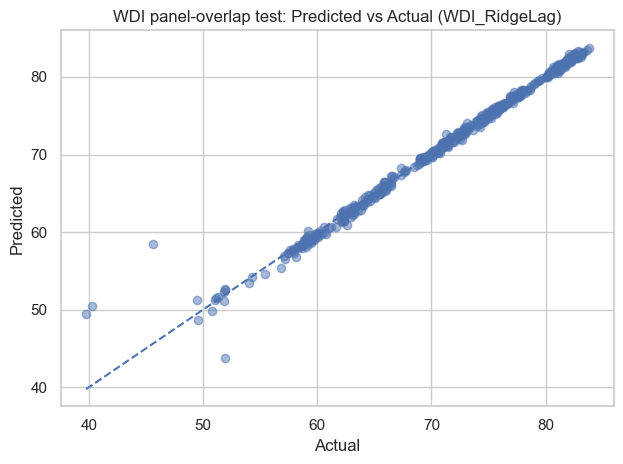

In [15]:
ax = plot_predicted_vs_actual(
    best_wdi_pred["y_true"],
    best_wdi_pred["y_pred"],
    title=f"WDI panel-overlap test: Predicted vs Actual ({best_wdi_model})",
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"wdi_pred_vs_actual_{best_wdi_model}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Residual vs Predicted 

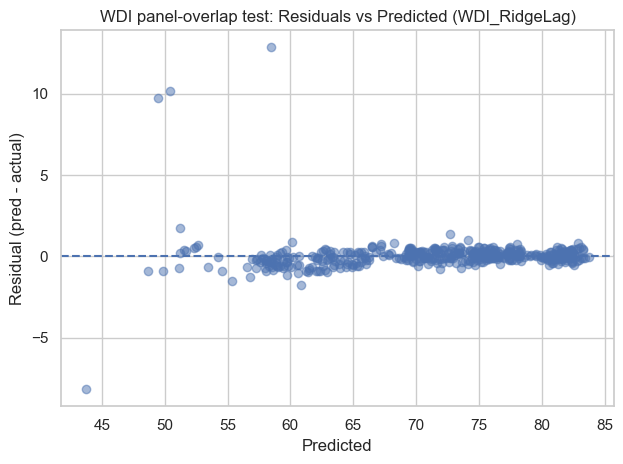

In [16]:
ax = plot_residuals_vs_predicted(
    best_wdi_pred["y_true"],
    best_wdi_pred["y_pred"],
    title=f"WDI panel-overlap test: Residuals vs Predicted ({best_wdi_model})",
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"wdi_residuals_vs_pred_{best_wdi_model}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Residual Histogram

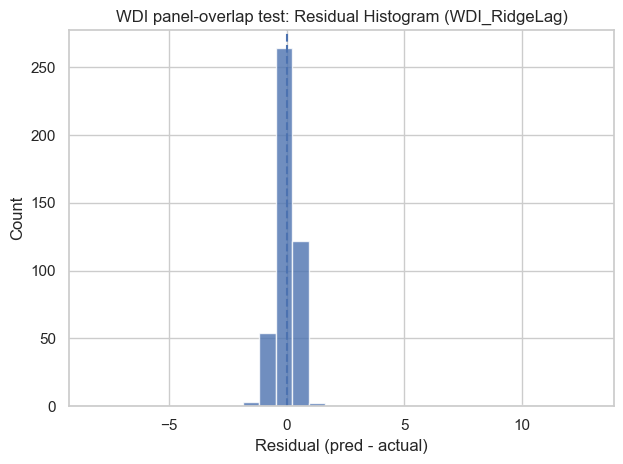

In [17]:
ax = plot_residual_hist(
    best_wdi_pred["y_true"],
    best_wdi_pred["y_pred"],
    title=f"WDI panel-overlap test: Residual Histogram ({best_wdi_model})",
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"wdi_residual_hist_{best_wdi_model}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## “Error by country” ranked plot 

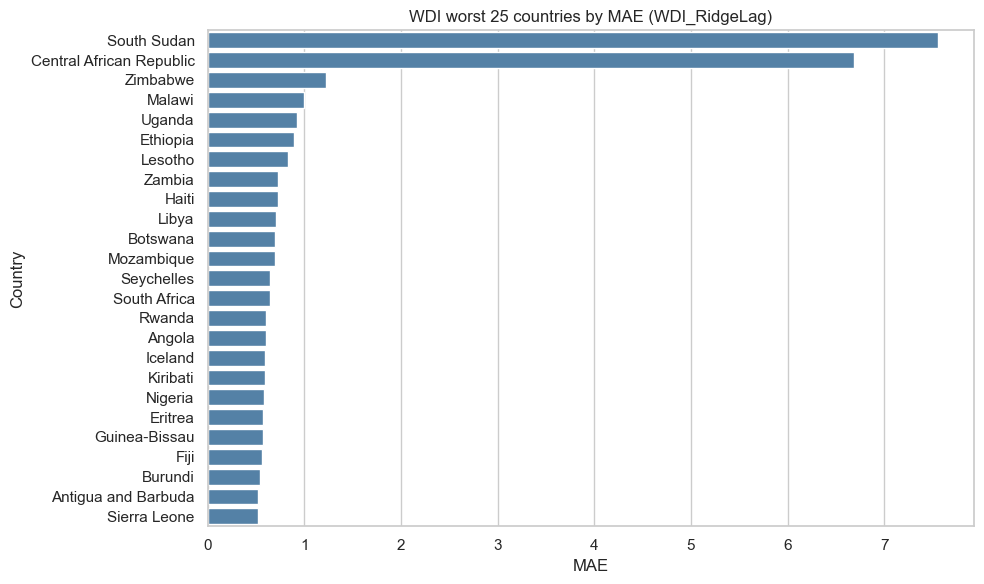

,country,mae
128,South Sudan,7.552391
27,Central African Republic,6.691035
149,Zimbabwe,1.223917
84,Malawi,0.993395
142,Uganda,0.924219
45,Ethiopia,0.891033
78,Lesotho,0.831700
148,Zambia,0.731376
59,Haiti,0.722210
80,Libya,0.707134


In [18]:
if "country" in best_wdi_pred.columns:
    wdi_mae_by_country = (
        best_wdi_pred.groupby("country", dropna=False)["abs_error"]
        .mean()
        .reset_index(name="mae")
        .sort_values("mae", ascending=False)
        .head(25)
    )

    wdi_mae_by_country.to_csv(
        TABLES_DIR / "wdi_best_model_worst_countries.csv",
        index=False,
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=wdi_mae_by_country,
        x="mae",
        y="country",
        color="steelblue",
    )
    plt.title(f"WDI worst 25 countries by MAE ({best_wdi_model})")
    plt.xlabel("MAE")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"wdi_worst_countries_{best_wdi_model}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    display(wdi_mae_by_country)

## 7. Compare WDI against panel-model results

The WDI models use fewer features but more historical years. The panel models use richer features but fewer years. This comparison is only meaningful if the panel outputs were evaluated on the same final overlapping years.

In [19]:
panel_result_paths = [
    TABLES_DIR / "external_boosting_compare.csv",
    TABLES_DIR / "lag_model_compare.csv",
    TABLES_DIR / "lag_vs_lstm.csv",
    TABLES_DIR / "advanced_model_comparison.csv",
]

panel_result_frames = []

for path in panel_result_paths:
    if path.exists():
        temp = pd.read_csv(path)
        temp["source_file"] = path.name
        temp["dataset"] = "Panel"
        panel_result_frames.append(temp)

if panel_result_frames:
    panel_results = pd.concat(panel_result_frames, ignore_index=True)
else:
    panel_results = pd.DataFrame()

print("Loaded panel result files:", len(panel_result_frames))
panel_results.head()

Loaded panel result files: 4


,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration,source_file,dataset,best_epoch,feature_set
0,xgb_cap_1200_sub0.8_col0.8,time,1661,151.0,453,1.504393,1.108446,0.967705,924.0,external_boosting_compare.csv,Panel,NaN,NaN
1,LightGBM_baseline,time,1661,151.0,453,1.645552,1.197233,0.961361,300.0,external_boosting_compare.csv,Panel,NaN,NaN
2,CatBoost_baseline,time,1661,151.0,453,1.680190,1.231490,0.959717,299.0,external_boosting_compare.csv,Panel,NaN,NaN
3,LagHistGBR,time_lagged,1359,NaN,453,0.782090,0.468453,0.991272,NaN,lag_model_compare.csv,Panel,NaN,NaN
4,LagRidgeCV,time_lagged,1359,NaN,453,0.934932,0.532570,0.987527,NaN,lag_model_compare.csv,Panel,NaN,NaN


## Final comparison table

In [20]:
wdi_results_for_compare = wdi_compare.copy()
wdi_results_for_compare["source_file"] = "wdi_panel_overlap_model_compare.csv"

common_cols = [
    "dataset",
    "model_name",
    "split_name",
    "n_train",
    "n_test",
    "rmse",
    "mae",
    "r2",
    "source_file",
]

if not panel_results.empty:
    panel_compare = panel_results.rename(columns={"model": "model_name"})
    panel_compare = panel_compare[
        [col for col in common_cols if col in panel_compare.columns]
    ].copy()

    wdi_compare_small = wdi_results_for_compare[
        [col for col in common_cols if col in wdi_results_for_compare.columns]
    ].copy()

    final_compare = pd.concat(
        [panel_compare, wdi_compare_small],
        ignore_index=True,
    )
else:
    final_compare = wdi_results_for_compare[
        [col for col in common_cols if col in wdi_results_for_compare.columns]
    ].copy()

final_compare = final_compare.sort_values("rmse")

final_compare.to_csv(
    TABLES_DIR / "panel_vs_wdi_model_compare.csv",
    index=False,
)

final_compare

,dataset,model_name,split_name,n_train,n_test,rmse,mae,r2,source_file
3,Panel,LagHistGBR,time_lagged,1359,453,0.782090,0.468453,0.991272,lag_model_compare.csv
5,Panel,LagHistGBR,time_lagged,1359,453,0.782090,0.468453,0.991272,lag_vs_lstm.csv
4,Panel,LagRidgeCV,time_lagged,1359,453,0.934932,0.532570,0.987527,lag_model_compare.csv
6,Panel,LagRidgeCV,time_lagged,1359,453,0.934932,0.532570,0.987527,lag_vs_lstm.csv
26,WDI,WDI_RidgeLag,panel_overlap_test,7346,450,1.057033,0.396265,0.984591,wdi_panel_overlap_model_compare.csv
27,WDI,WDI_ExtraTrees_Lag,panel_overlap_test,7346,450,1.095014,0.329123,0.983464,wdi_panel_overlap_model_compare.csv
28,WDI,WDI_HistGBR_Lag,panel_overlap_test,7346,450,1.249877,0.400798,0.978456,wdi_panel_overlap_model_compare.csv
29,WDI,WDI_RandomForest_Lag,panel_overlap_test,7346,450,1.336096,0.401976,0.975381,wdi_panel_overlap_model_compare.csv
7,Panel,lstm_delta,time_sequence,1208,453,1.352221,0.857426,0.973908,lag_vs_lstm.csv
30,WDI,WDI_XGB_Lag,panel_overlap_test,7346,450,1.394920,0.438212,0.973165,wdi_panel_overlap_model_compare.csv


## Panel vs WDI comparison plot

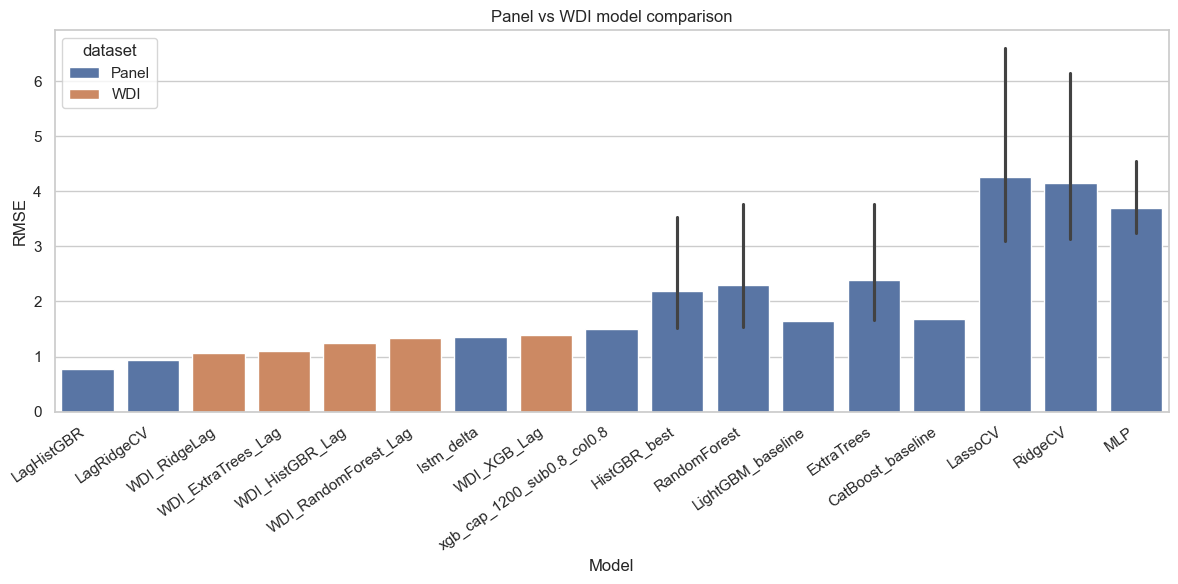

In [21]:
plot_df = final_compare.dropna(subset=["rmse"]).copy()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="model_name",
    y="rmse",
    hue="dataset",
)

plt.title("Panel vs WDI model comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "panel_vs_wdi_rmse_compare.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()